# Vendor Performance: Data Quality and Exploratory Analysis

**Data Analyst objective:** understand the existing MySQL data, describe commercial patterns, identify unusual observations, and establish reliable inputs for the business analysis.

**Scope:** source structure, data-quality diagnostics, descriptive statistics, distributions, time trends, vendor and brand patterns, outliers, correlations, inventory reconciliation, and KPI definitions.

This notebook is read-only. The database is already populated; it does not create, replace, or ingest tables.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
(ROOT / "images").mkdir(exist_ok=True)
load_dotenv(ROOT / ".env")

required = ["MYSQL_USER", "MYSQL_PASSWORD", "MYSQL_HOST", "MYSQL_DB"]
missing = [name for name in required if not os.getenv(name)]
if missing:
    raise RuntimeError(f"Missing MySQL settings: {', '.join(missing)}")

engine = create_engine(URL.create(
    "mysql+pymysql",
    username=os.getenv("MYSQL_USER"),
    password=os.getenv("MYSQL_PASSWORD"),
    host=os.getenv("MYSQL_HOST"),
    database=os.getenv("MYSQL_DB"),
))

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

## 1. Source-system inventory and analytical grain

In [2]:
tables = pd.read_sql_query("""
SELECT
    table_name AS TableName,
    table_rows AS ApproximateRows
FROM information_schema.tables
WHERE table_schema = DATABASE()
ORDER BY table_name
""", engine)
display(tables)

,TableName,ApproximateRows
0,begin_inventory,204057
1,end_inventory,221245
2,purchase_prices,12214
3,purchases,2162655
4,sales,12618134
5,vendor_invoice,5308
6,vendor_sales_summary,10124


### Analytical grain

| Table | Grain | Business use |
|---|---|---|
| `sales` | store-SKU-day transaction | Revenue and units sold |
| `purchases` | received PO line | Procurement quantity and cost |
| `vendor_invoice` | vendor-PO-invoice | Freight and invoice control |
| `purchase_prices` | vendor-item price reference | Cost and retail-price context |
| `begin_inventory` | store-SKU opening snapshot | Available inventory |
| `end_inventory` | store-SKU closing snapshot | Ending exposure |

The published vendor dataset must first aggregate sales and purchases separately to one vendor-brand row. Joining raw facts, or grouping purchases by changing price before joining sales, can duplicate revenue.

## 2. Transaction-level data-quality snapshot

These checks describe the analytical inputs without repeating the completed ingestion process. Non-positive commercial values are surfaced for investigation rather than silently deleted.

In [3]:
quality = pd.read_sql_query("""
SELECT 'sales' AS SourceTable,
       COUNT(*) AS RowCount,
       SUM(VendorNo IS NULL OR Brand IS NULL OR SalesDate IS NULL) AS MissingKeyRows,
       SUM(SalesQuantity <= 0) AS NonPositiveQuantityRows,
       SUM(SalesDollars <= 0) AS NonPositiveDollarRows
FROM sales
UNION ALL
SELECT 'purchases', COUNT(*),
       SUM(VendorNumber IS NULL OR Brand IS NULL OR PODate IS NULL),
       SUM(Quantity <= 0), SUM(Dollars <= 0)
FROM purchases
""", engine)

for column in ["MissingKeyRows", "NonPositiveQuantityRows", "NonPositiveDollarRows"]:
    quality[column.replace("Rows", "Pct")] = 100 * quality[column] / quality["RowCount"]
display(quality)

,SourceTable,RowCount,MissingKeyRows,NonPositiveQuantityRows,NonPositiveDollarRows,MissingKeyPct,NonPositiveQuantityPct,NonPositiveDollarPct
0,sales,12825363,0.0,0.0,55.0,0.0,0.0,0.000429
1,purchases,2372474,0.0,0.0,153.0,0.0,0.0,0.006449


**Interpretation:** key completeness and non-positive-value rates provide a concise diagnostic baseline. Legitimate returns or adjustments should be handled through business rules; they should not be removed solely because they appear as statistical exceptions.

## 3. Descriptive statistics and numeric distributions

In [4]:
eda_sql = """
WITH SalesSummary AS (
    SELECT VendorNo AS VendorNumber, MAX(TRIM(VendorName)) AS VendorName,
           Brand, MAX(TRIM(Description)) AS Description,
           SUM(SalesQuantity) AS SalesQuantity, SUM(SalesDollars) AS SalesDollars
    FROM sales
    GROUP BY VendorNo, Brand
),
PurchaseSummary AS (
    SELECT VendorNumber, Brand, SUM(Quantity) AS PurchaseQuantity,
           SUM(Dollars) AS PurchaseDollars,
           SUM(Dollars) / NULLIF(SUM(Quantity), 0) AS WeightedUnitCost
    FROM purchases
    GROUP BY VendorNumber, Brand
)
SELECT s.VendorNumber, s.VendorName, s.Brand, s.Description,
       s.SalesQuantity, s.SalesDollars,
       p.PurchaseQuantity, p.PurchaseDollars, p.WeightedUnitCost,
       s.SalesDollars / NULLIF(s.SalesQuantity, 0) AS AverageSellingPrice,
       s.SalesQuantity * p.WeightedUnitCost AS EstimatedCOGS,
       s.SalesDollars - s.SalesQuantity * p.WeightedUnitCost AS EstimatedGrossProfit,
       100 * (s.SalesDollars - s.SalesQuantity * p.WeightedUnitCost)
           / NULLIF(s.SalesDollars, 0) AS WeightedMarginPct
FROM SalesSummary s
JOIN PurchaseSummary p
  ON s.VendorNumber = p.VendorNumber AND s.Brand = p.Brand
"""

eda_metrics = pd.read_sql_query(eda_sql, engine)
numeric_columns = [
    "SalesQuantity", "SalesDollars", "PurchaseQuantity", "PurchaseDollars",
    "WeightedUnitCost", "AverageSellingPrice", "EstimatedGrossProfit", "WeightedMarginPct",
]
display(eda_metrics[numeric_columns].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T.round(2))
print(f"Analytical grain: {len(eda_metrics):,} cost-matched vendor-brand rows")

,count,mean,std,min,25%,50%,75%,95%,max
SalesQuantity,10515.0,3129.45,11037.28,1.00,36.00,280.00,1985.00,13835.20,334939.00
SalesDollars,10515.0,42959.43,168970.58,1.98,809.82,5599.72,29529.41,175261.91,5101919.51
PurchaseQuantity,10515.0,3192.74,11180.81,1.00,36.00,281.00,2028.50,14103.80,337660.00
PurchaseDollars,10515.0,30586.65,124042.31,0.00,478.17,3835.15,21279.54,120565.16,3811251.60
WeightedUnitCost,10515.0,23.41,92.17,0.00,6.84,10.45,19.37,61.60,4264.70
AverageSellingPrice,10515.0,33.79,126.24,0.49,10.44,15.49,27.99,89.99,5799.99
EstimatedGrossProfit,10515.0,13177.99,48101.57,-24762.39,246.53,1572.60,9083.19,56933.18,1370292.28
WeightedMarginPct,10515.0,31.74,9.35,-174.58,28.24,32.89,35.46,43.26,100.00


Analytical grain: 10,515 cost-matched vendor-brand rows


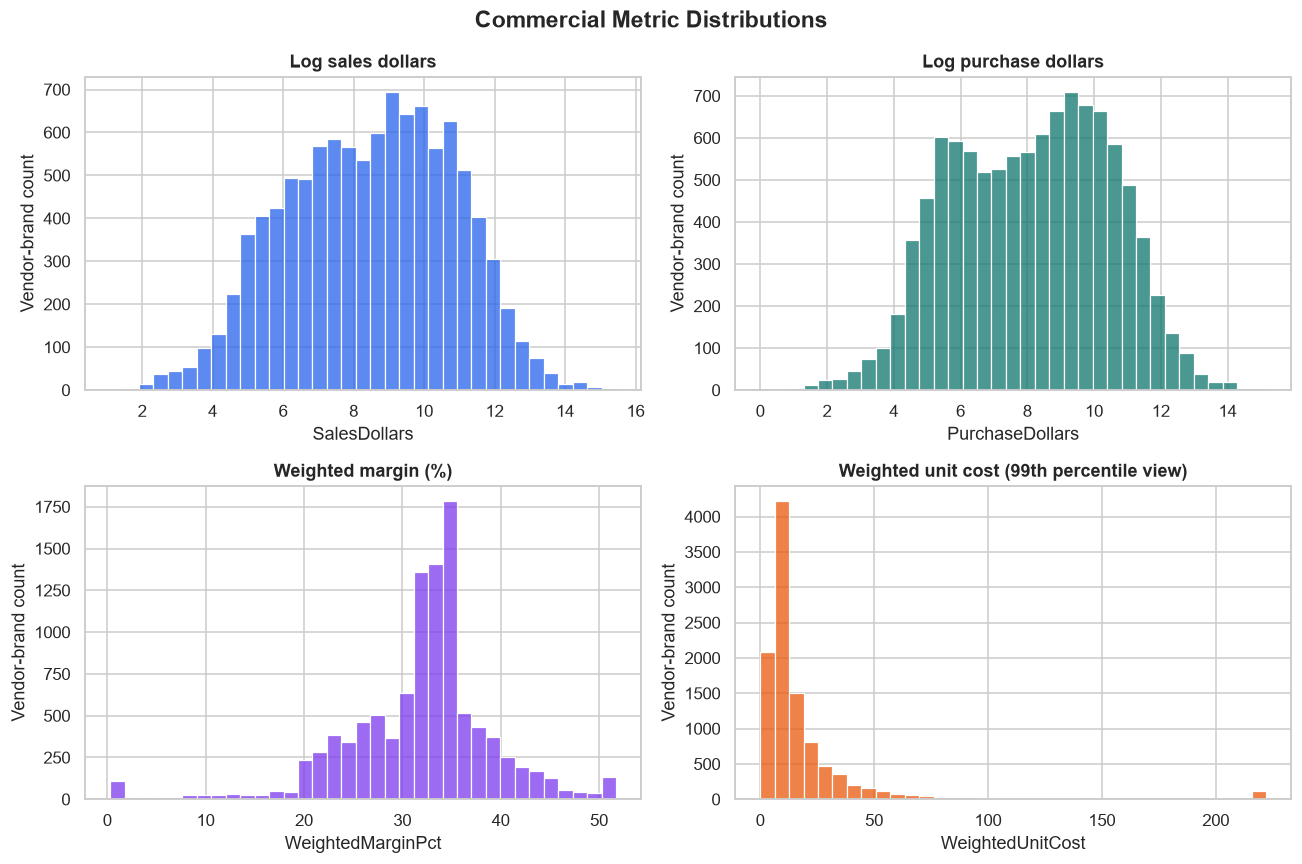

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (np.log1p(eda_metrics["SalesDollars"].clip(lower=0)), "Log sales dollars", "#2563eb"),
    (np.log1p(eda_metrics["PurchaseDollars"].clip(lower=0)), "Log purchase dollars", "#0f766e"),
    (eda_metrics["WeightedMarginPct"].clip(*eda_metrics["WeightedMarginPct"].quantile([0.01, 0.99])), "Weighted margin (%)", "#7c3aed"),
    (eda_metrics["WeightedUnitCost"].clip(upper=eda_metrics["WeightedUnitCost"].quantile(0.99)), "Weighted unit cost (99th percentile view)", "#ea580c"),
]
for ax, (values, title, color) in zip(axes.flat, plots):
    sns.histplot(values.dropna(), bins=35, ax=ax, color=color)
    ax.set_title(title)
    ax.set_ylabel("Vendor-brand count")
fig.suptitle("Commercial Metric Distributions", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(ROOT / "images" / "eda_distributions.png", bbox_inches="tight")
plt.show()

**Interpretation:** sales and procurement values are strongly right-skewed, so medians and percentile bands are more representative than simple means. Extreme observations remain in the analytical population because large vendors and brands are commercially meaningful, not automatically erroneous.

## 4. Monthly sales and procurement trends

,Month,SalesDollars,SalesUnits,PurchaseDollars,PurchaseUnits
0,2023-12,NaN,NaN,6.950117e+06,705759.0
1,2024-01,2.985403e+07,2194959.0,1.913882e+07,2130443.0
2,2024-02,2.887661e+07,2125292.0,2.014736e+07,2242110.0
3,2024-03,2.898841e+07,2219626.0,2.025297e+07,2199278.0
4,2024-04,3.072373e+07,2289425.0,2.179873e+07,2328996.0
5,2024-05,3.604121e+07,2624496.0,2.869306e+07,3011592.0
6,2024-06,3.929070e+07,2858944.0,2.969919e+07,3038355.0
7,2024-07,4.969647e+07,3439648.0,3.219384e+07,3252027.0
8,2024-08,3.905617e+07,2892266.0,3.074788e+07,3224148.0
9,2024-09,3.847754e+07,2840043.0,2.684092e+07,2906400.0


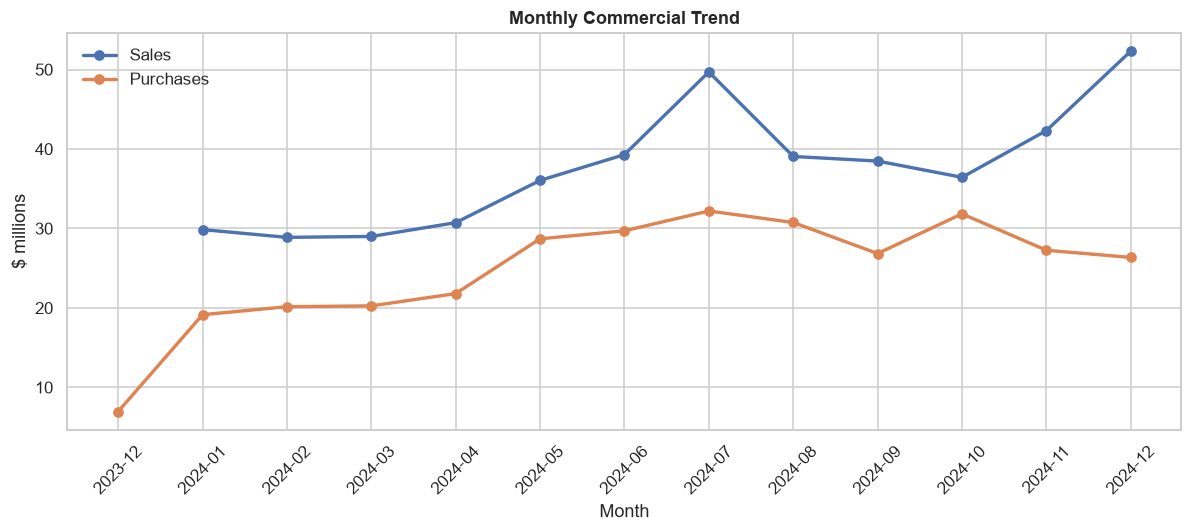

In [6]:
monthly_sales = pd.read_sql_query("""
SELECT DATE_FORMAT(SalesDate, '%%Y-%%m') AS Month,
       SUM(SalesDollars) AS SalesDollars,
       SUM(SalesQuantity) AS SalesUnits
FROM sales
GROUP BY DATE_FORMAT(SalesDate, '%%Y-%%m')
ORDER BY Month
""", engine)

monthly_purchases = pd.read_sql_query("""
SELECT DATE_FORMAT(PODate, '%%Y-%%m') AS Month,
       SUM(Dollars) AS PurchaseDollars,
       SUM(Quantity) AS PurchaseUnits
FROM purchases
GROUP BY DATE_FORMAT(PODate, '%%Y-%%m')
ORDER BY Month
""", engine)

monthly = monthly_sales.merge(monthly_purchases, on="Month", how="outer").sort_values("Month")
display(monthly)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["Month"], monthly["SalesDollars"] / 1e6, marker="o", linewidth=2.2, label="Sales")
ax.plot(monthly["Month"], monthly["PurchaseDollars"] / 1e6, marker="o", linewidth=2.2, label="Purchases")
ax.set(title="Monthly Commercial Trend", xlabel="Month", ylabel="$ millions")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ROOT / "images" / "eda_monthly_trends.png", bbox_inches="tight")
plt.show()

**Interpretation:** monthly sales and procurement are reviewed together to identify seasonality, purchasing lead/lag patterns, and periods that deserve operational follow-up. The chart is descriptive; timing differences do not by themselves establish a vendor-performance issue.

## 5. Vendor and brand concentration patterns

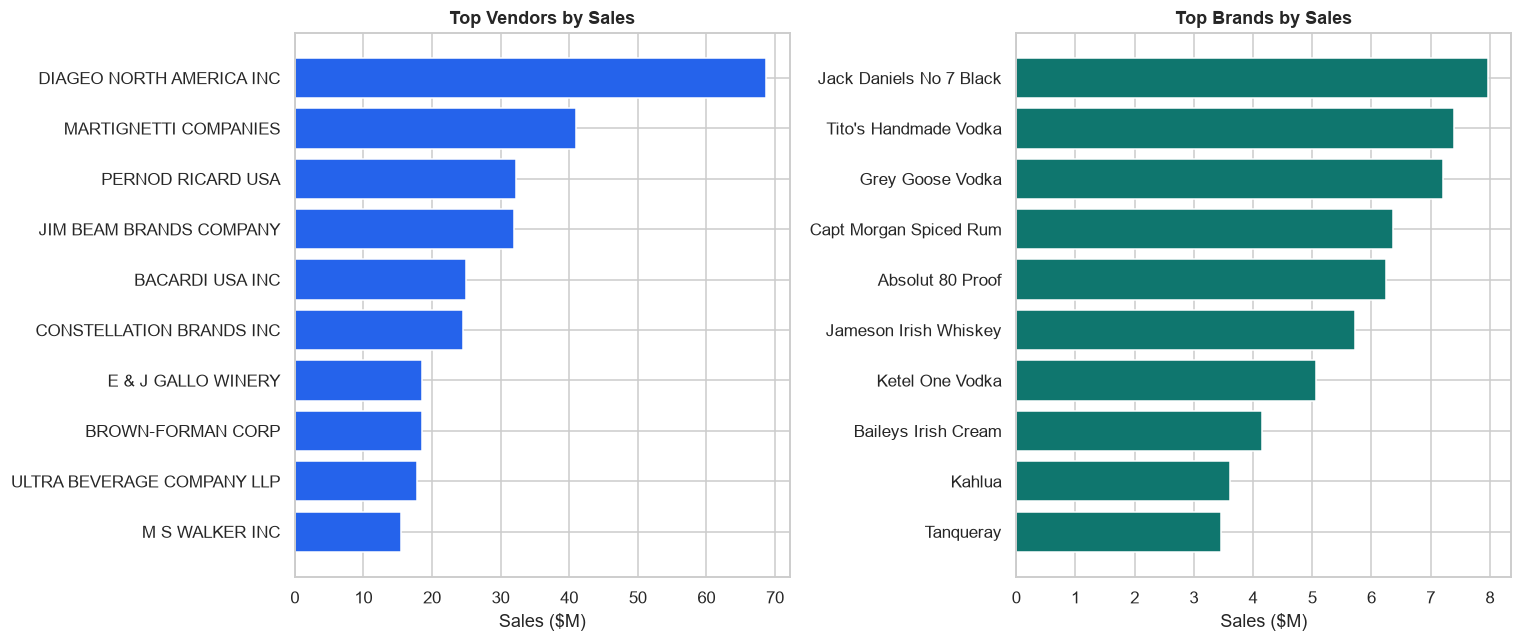

In [7]:
top_vendors = (eda_metrics.groupby("VendorName", as_index=False)["SalesDollars"].sum()
               .nlargest(10, "SalesDollars").sort_values("SalesDollars"))
top_brands = (eda_metrics.groupby("Description", as_index=False)["SalesDollars"].sum()
              .nlargest(10, "SalesDollars").sort_values("SalesDollars"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_vendors["VendorName"], top_vendors["SalesDollars"] / 1e6, color="#2563eb")
axes[0].set(title="Top Vendors by Sales", xlabel="Sales ($M)", ylabel="")
axes[1].barh(top_brands["Description"], top_brands["SalesDollars"] / 1e6, color="#0f766e")
axes[1].set(title="Top Brands by Sales", xlabel="Sales ($M)", ylabel="")
fig.tight_layout()
fig.savefig(ROOT / "images" / "eda_category_patterns.png", bbox_inches="tight")
plt.show()

**Interpretation:** the leading vendors and brands establish the commercial context for the later concentration and portfolio analyses. High sales is not treated as sufficient evidence of strong margin, low risk, or efficient inventory.

## 6. Outlier profile and relationships

,Metric,IQRFlaggedRows,FlaggedPct
0,SalesDollars,1350,12.84
1,PurchaseDollars,1334,12.69
2,WeightedUnitCost,1056,10.04
3,WeightedMarginPct,608,5.78


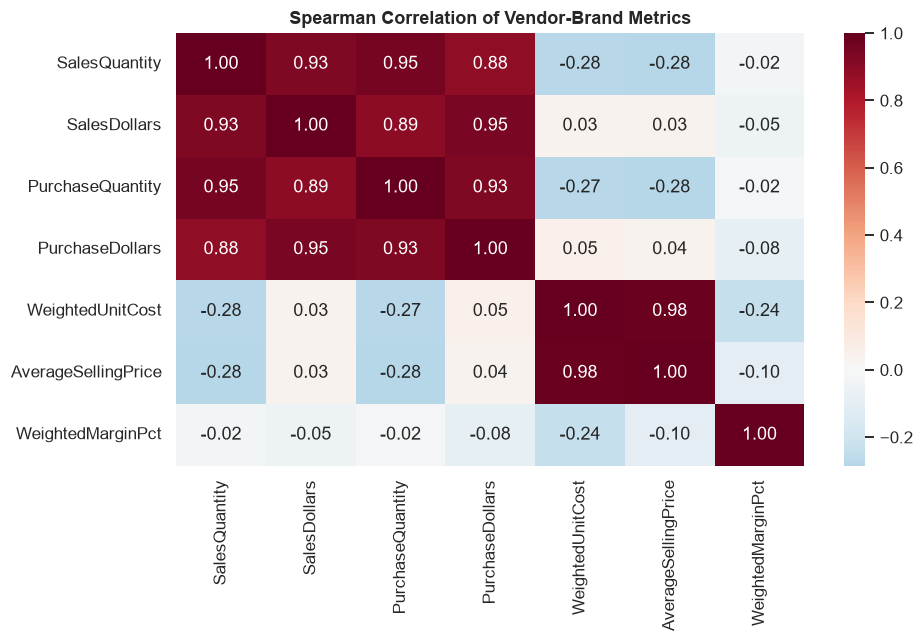

In [8]:
outlier_rows = []
for column in ["SalesDollars", "PurchaseDollars", "WeightedUnitCost", "WeightedMarginPct"]:
    q1, q3 = eda_metrics[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (eda_metrics[column] < q1 - 1.5 * iqr) | (eda_metrics[column] > q3 + 1.5 * iqr)
    outlier_rows.append((column, int(mask.sum()), 100 * mask.mean()))
outlier_profile = pd.DataFrame(outlier_rows, columns=["Metric", "IQRFlaggedRows", "FlaggedPct"])
display(outlier_profile.round(2))

corr_columns = ["SalesQuantity", "SalesDollars", "PurchaseQuantity", "PurchaseDollars", "WeightedUnitCost", "AverageSellingPrice", "WeightedMarginPct"]
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(eda_metrics[corr_columns].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Spearman Correlation of Vendor-Brand Metrics")
fig.tight_layout()
fig.savefig(ROOT / "images" / "eda_correlation.png", bbox_inches="tight")
plt.show()

**Interpretation:** IQR flags identify observations for review, not deletion. Spearman correlation is used because the distributions are skewed; relationships are interpreted as associations and not as causal effects.

## 7. Existing summary-table diagnostic

In [9]:
summary_quality = pd.read_sql_query("""
SELECT
    COUNT(*) AS SummaryRows,
    COUNT(DISTINCT CONCAT(VendorNumber, '-', Brand)) AS DistinctVendorBrands,
    SUM(TotalSalesDollars = 0) AS ZeroSalesRows,
    SUM(GrossProfit <= 0) AS NonPositiveLegacyProfitRows,
    SUM(TotalSalesQuantity > TotalPurchaseQuantity) AS SalesAboveCurrentPurchases
FROM vendor_sales_summary
""", engine)
display(summary_quality)

,SummaryRows,DistinctVendorBrands,ZeroSalesRows,NonPositiveLegacyProfitRows,SalesAboveCurrentPurchases
0,10692,10692,178.0,2127.0,3495.0


**Interpretation:** sales above current-period purchases is not automatically an error because beginning inventory can satisfy sales. Loss-making and zero-sales records are decision-relevant and should not be deleted simply to improve averages. The analytical notebook therefore uses weighted calculations and explicit denominator guards.

## 8. Inventory reconciliation

In [10]:
reconciliation = pd.read_sql_query("""
SELECT
    (SELECT SUM(onHand) FROM begin_inventory) AS BeginningUnits,
    (SELECT SUM(Quantity) FROM purchases) AS PurchasedUnits,
    (SELECT SUM(SalesQuantity) FROM sales) AS SoldUnits,
    (SELECT SUM(onHand) FROM end_inventory) AS EndingUnits,
    (SELECT SUM(onHand * Price) FROM end_inventory) AS EndingRetailValue
""", engine)

reconciliation["ExpectedEndingUnits"] = (
    reconciliation["BeginningUnits"]
    + reconciliation["PurchasedUnits"]
    - reconciliation["SoldUnits"]
)
reconciliation["ResidualUnits"] = reconciliation["EndingUnits"] - reconciliation["ExpectedEndingUnits"]
display(reconciliation.T.rename(columns={0: "Value"}))

assert reconciliation.loc[0, "ResidualUnits"] == 0, "Aggregate inventory does not reconcile"

,Value
BeginningUnits,4219275.00
PurchasedUnits,33584377.00
SoldUnits,32917876.00
EndingUnits,4885776.00
EndingRetailValue,79704851.13
ExpectedEndingUnits,4885776.00
ResidualUnits,0.00


The aggregate inventory equation reconciles exactly: beginning units plus purchases minus sales equals ending units. This is a strong completeness check, while lower-grain returns or adjustments may still exist.

## 9. KPI dictionary

In [11]:
kpi_dictionary = pd.DataFrame([
    ("Total Sales", "SUM(SalesDollars)", "Revenue scale"),
    ("Procurement Spend", "SUM(PurchaseDollars)", "Supplier spend"),
    ("Estimated COGS", "SalesQuantity x weighted purchase cost", "Cost proxy"),
    ("Weighted Gross Margin", "(Sales - Estimated COGS) / Sales", "Portfolio profitability"),
    ("Sell-Through", "Sales / (Beginning Inventory + Purchases)", "Inventory movement"),
    ("Inventory Turnover", "Sales / average beginning and ending inventory", "Stock efficiency"),
    ("Ending Inventory Retail Value", "Ending on-hand x retail price", "Year-end exposure"),
], columns=["KPI", "Definition", "DecisionUse"])
display(kpi_dictionary)

,KPI,Definition,DecisionUse
0,Total Sales,SUM(SalesDollars),Revenue scale
1,Procurement Spend,SUM(PurchaseDollars),Supplier spend
2,Estimated COGS,SalesQuantity x weighted purchase cost,Cost proxy
3,Weighted Gross Margin,(Sales - Estimated COGS) / Sales,Portfolio profitability
4,Sell-Through,Sales / (Beginning Inventory + Purchases),Inventory movement
5,Inventory Turnover,Sales / average beginning and ending inventory,Stock efficiency
6,Ending Inventory Retail Value,Ending on-hand x retail price,Year-end exposure


## 10. Guardrails and limitations

- Estimated COGS is a management proxy, not an audited FIFO/LIFO calculation.
- Ending inventory is valued at retail because the snapshot contains retail price; it is not labelled as cash locked at cost.
- Freight is measured once per vendor. Repeating the full vendor freight total on every brand would overstate logistics cost.
- Purchase volume and unit cost can be associated because product mix differs. The analysis does not call that relationship a causal bulk discount.
- All public margin rates are revenue-weighted; row percentages are never summed or averaged without weights.

**Outcome:** the data is suitable for decision analysis when these definitions and limitations travel with the results.